In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
y = np.load("/home/pi/Desktop/Camp2Code/Car/images/y.npy")  # gegebenfalls Pfad von y.npy anpassen
y = np.sort(y)
df = pd.DataFrame(data=y)

In [3]:
df.value_counts()
foo_1 = [val for val in df.value_counts()]
foo_2 = [val for val in df.value_counts().index]

In [4]:
df = pd.DataFrame(data=[foo_1, foo_2], index=["Häufigkeit", "Lenkwinkel"])
df = df.T
foo = [int(val[0]) for val in df["Lenkwinkel"]]
df["Lenkwinkel"] = foo

In [5]:
idx_1 = df["Lenkwinkel"] < 80
idx_2 = df["Lenkwinkel"] > 100
idx_3 = df["Lenkwinkel"] >= 80
idx_4 = df["Lenkwinkel"] <= 100
idx_5 = idx_3 & idx_4

print(f'Die Anzahl der Lenkwinkel nach links: {df[idx_1]["Häufigkeit"].sum()}')
print(f'Die Anzahl der Lenkwinkel nach rechts: {df[idx_2]["Häufigkeit"].sum()}')
print(f'Die Anzahl der Lenkwinkel nach geradeaus: {df[idx_5]["Häufigkeit"].sum()}')
print(f"Summe aller Bilder: {len(y)}")

Die Anzahl der Lenkwinkel nach links: 1340
Die Anzahl der Lenkwinkel nach rechts: 677
Die Anzahl der Lenkwinkel nach geradeaus: 402
Summe aller Bilder: 2419


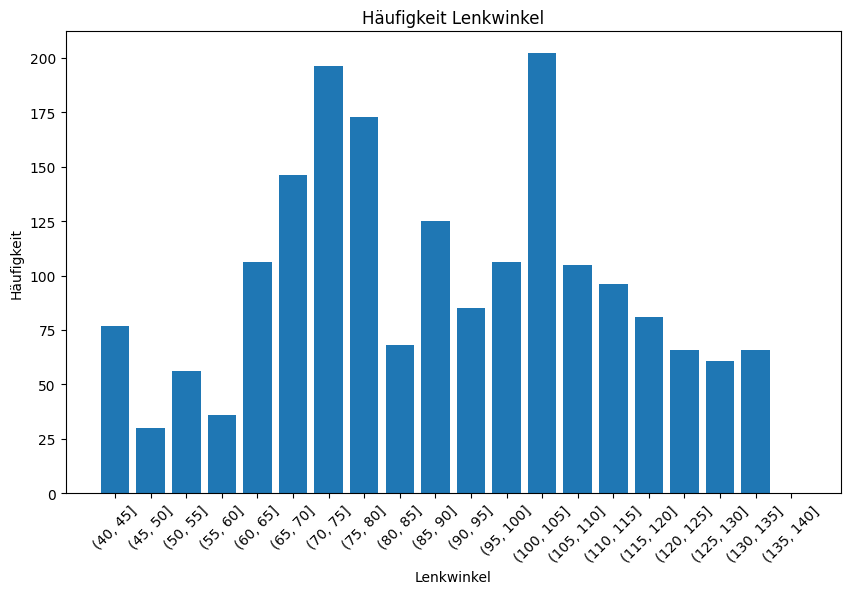

In [6]:
bins = range(40, 141, 5)
df['Lenkwinkel_grp'] = pd.cut(df['Lenkwinkel'], bins=bins)
grouped = df.groupby('Lenkwinkel_grp')['Häufigkeit'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(grouped['Lenkwinkel_grp'].astype(str), grouped['Häufigkeit'])

plt.xlabel('Lenkwinkel')
plt.ylabel('Häufigkeit')
plt.title('Häufigkeit Lenkwinkel')
plt.xticks(rotation=45)
plt.show()